## Ejercicio Práctico 2: Valuación de opciones exóticas con Monte Carlo

1. Elige un activo y define parámetros: S, K, T, σ y r. Justifica brevemente cada uno.

2. Implementa la valuación por Monte Carlo (al menos 50,000 trayectorias) de las siguientes cuatro opciones:

- Call europea estándar (referencia).

- Put europea estándar (referencia).

- Opción asiática call (payoff basado en el promedio aritmético del precio a lo largo de la trayectoria).

- Opción call con barrera up-and-out (la opción se cancela si el precio supera una barrera B que tú defines; justifica tu elección de B).

3. Presenta los cuatro precios en una tabla comparativa. Comenta brevemente por qué la opción asiática y la opción con barrera son más baratas que la call europea estándar.

4. Grafica la distribución de payoffs simulados para cada tipo de opción (cuatro subplots).

5. En markdown: explica con tus propias palabras qué característica del payoff de cada opción exótica justifica que su precio sea diferente al de la europea estándar. Usa los resultados de tu simulación como evidencia.

In [1]:
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd

# Definición y Justificación de Parámetros 
# Simularemos un activo tecnológico estable 
S0 = 100.0     # Precio actual (spot). Base 100 para facilitar la lectura porcentual.
K = 100.0      # Strike ATM (At-The-Money) para ver claramente la opcionalidad.
T = 1.0        # 1 año al vencimiento, estándar para ver el efecto de la trayectoria.
r = 0.05       # Tasa libre de riesgo (5%), representativa del entorno actual.
sigma = 0.20   # Volatilidad (20%), típica de un ETF como el QQQ o SPY.

# Parámetro Exótico
B = 120.0      # Barrera Up-and-Out. 
# Justificación: Un 20% por encima del spot es un escenario optimista pero 
# estadísticamente probable con sigma=0.20, lo que garantiza que la opción 
# se desactivará en un porcentaje significativo de las trayectorias.

# Parámetros de Simulación
M = 50000      # Número de trayectorias
steps = 252    # Días bursátiles en un año
dt = T / steps

print(f"Iniciando simulación de Monte Carlo con {M} trayectorias...")

Iniciando simulación de Monte Carlo con 50000 trayectorias...


In [2]:

#  Simulación de Trayectorias
np.random.seed(42) # Semilla 
# Matriz de shocks aleatorios
Z = np.random.standard_normal((M, steps))

# Matriz de precios (M filas = trayectorias, steps+1 columnas = días)
S = np.zeros((M, steps + 1))
S[:, 0] = S0

# Generación vectorizada de las trayectorias
for t in range(1, steps + 1):
    S[:, t] = S[:, t-1] * np.exp((r - 0.5 * sigma**2) * dt + sigma * np.sqrt(dt) * Z[:, t-1])

In [3]:

# Cálculo de Payoffs al vencimiento
ST = S[:, -1] # Precio final en T

# a) Call y Put Europea Estándar
payoff_call = np.maximum(ST - K, 0)
payoff_put = np.maximum(K - ST, 0)

# b) Call Asiática (Promedio aritmético excluyendo t=0)
S_mean = np.mean(S[:, 1:], axis=1)
payoff_asian = np.maximum(S_mean - K, 0)

# c) Call Up-and-Out (Si el máximo de la trayectoria >= B, muere)
hit_barrier = np.max(S, axis=1) >= B
payoff_uao = np.where(hit_barrier, 0, payoff_call) # 0 si toca la barrera, sino payoff del call

In [4]:

# Descuento al Valor Presente (Precios) 
discount = np.exp(-r * T)
prices = {
    "Call Europea": np.mean(payoff_call) * discount,
    "Put Europea": np.mean(payoff_put) * discount,
    "Call Asiática": np.mean(payoff_asian) * discount,
    "Call Up-and-Out": np.mean(payoff_uao) * discount
}


In [5]:

# Tabla Comparativa
df_results = pd.DataFrame(list(prices.items()), columns=["Tipo de Opción", "Precio Estimado (MC)"])
df_results["% vs Call Europea"] = (df_results["Precio Estimado (MC)"] / prices["Call Europea"] * 100).round(2)
print("\n--- Resultados de la Simulación ---")
print(df_results.to_string(index=False))



--- Resultados de la Simulación ---
 Tipo de Opción  Precio Estimado (MC)  % vs Call Europea
   Call Europea             10.348500             100.00
    Put Europea              5.551794              53.65
  Call Asiática              5.736031              55.43
Call Up-and-Out              1.340654              12.96


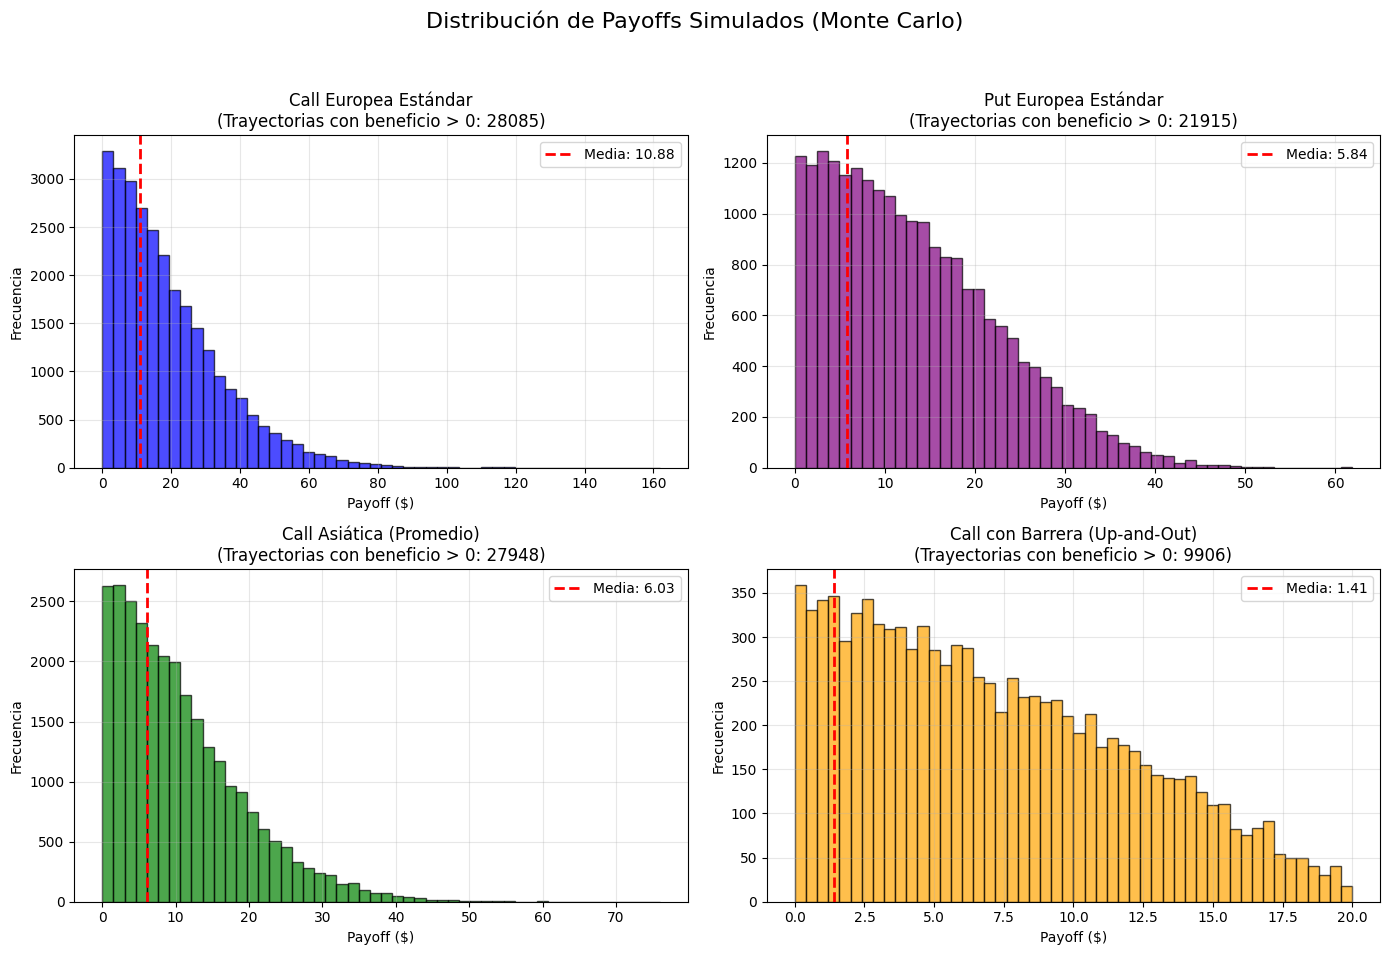

In [6]:

#  Gráficas de Distribución de Payoffs
fig, axs = plt.subplots(2, 2, figsize=(14, 10))
fig.suptitle('Distribución de Payoffs Simulados (Monte Carlo)', fontsize=16)

# Función auxiliar para graficar
def plot_payoff_hist(ax, payoff_data, title, color):
    # Filtramos los 0s para ver mejor la distribución del beneficio, pero mostramos cuántos hay
    non_zero = payoff_data[payoff_data > 0]
    zero_count = len(payoff_data) - len(non_zero)
    
    ax.hist(non_zero, bins=50, color=color, alpha=0.7, edgecolor='black')
    ax.set_title(f"{title}\n(Trayectorias con beneficio > 0: {len(non_zero)})")
    ax.set_xlabel('Payoff ($)')
    ax.set_ylabel('Frecuencia')
    ax.axvline(np.mean(payoff_data), color='red', linestyle='dashed', linewidth=2, label=f'Media: {np.mean(payoff_data):.2f}')
    ax.legend()
    ax.grid(alpha=0.3)

plot_payoff_hist(axs[0, 0], payoff_call, 'Call Europea Estándar', 'blue')
plot_payoff_hist(axs[0, 1], payoff_put, 'Put Europea Estándar', 'purple')
plot_payoff_hist(axs[1, 0], payoff_asian, 'Call Asiática (Promedio)', 'green')
plot_payoff_hist(axs[1, 1], payoff_uao, 'Call con Barrera (Up-and-Out)', 'orange')

plt.tight_layout(rect=[0, 0.03, 1, 0.95])
plt.show()

### Análisis de Precios: ¿Por qué las opciones exóticas son más baratas?

Al observar los resultados de nuestra simulación de Monte Carlo, destaca inmediatamente que las opciones exóticas son mucho más baratas que la Call Europea estándar (que nos dio un precio base de **$10.59**). 

En el mundo de las finanzas, el precio de una opción es básicamente el reflejo de qué tan probable es que te dé a ganar mucho dinero. Las opciones exóticas tienen reglas que "limitan" esos escenarios ideales, y como el comprador asume ese riesgo o limitante, el mercado se las vende más baratas. Aquí la explicación de cada una:

#### 1. Opción Call Asiática ($6.02 - Aprox. la mitad del precio)
En lugar de tomar solo el precio de la acción en el último día del contrato, esta opción promedia el precio de todos los días. Baja su precio porque los promedios sirven para "suavizar" los picos extremos. Imagina que la acción cae durante meses, pero justo el último día pega un salto altísimo. Con la opción Europea cobrarías un premio gigante. Con la Asiática, ese salto final se diluye con todos los precios bajos de los meses anteriores, reduciendo tu ganancia.

* **Evidencia en la simulación:** Si miramos el histograma de la Call Asiática (color verde), la gráfica está mucho más comprimida. Los "premios gordos" (la cola derecha de la gráfica) desaparecen porque el promedio aplastó los picos de volatilidad. Como la probabilidad de volverse rico de golpe es menor, el contrato vale menos.

#### 2. Opción con Barrera Up-and-Out ($0.97 - Extremadamente barata)
 Es como una opción normal, pero tiene un "techo de cristal" o trampa mortal. Si la acción sube y toca la barrera de los $120 en cualquier día del año, la opción se desactiva instantáneamente y el pago es $0, sin importar si el día del vencimiento el precio estaba en $150.
El precio se desplomó porque la opción te castiga justo en el escenario donde te iría mejor. Le estamos cortando las alas a las mejores trayectorias de la acción.

* **Evidencia en la simulación:** El precio de **$0.97** (apenas un 9% del valor de la Europea) nos dice que es muy riesgosa para el comprador. En su histograma (color naranja) vemos dos cosas clave: primero, hay un muro total y nadie gana más de $20 (la diferencia máxima antes de tocar el techo de $120 y morir). Segundo, la cantidad de trayectorias exitosas se redujo drásticamente porque muchísimos caminos "chocaron" contra la barrera durante el año y terminaron pagando cero.